# Example

Elements of Data Science

by [Allen Downey](https://allendowney.com)

Updated by [Tiniaco Leyba](https://tiniacoleyba.com/) in May 2025

[MIT License](https://opensource.org/licenses/MIT)

## Vaccines and GDP

This example is based on an article in *The Economist*,
[Conspiracy theories about covid-19 vaccines may prevent herd immunity](https://www.economist.com/graphic-detail/2020/08/29/conspiracy-theories-about-covid-19-vaccines-may-prevent-herd-immunity).

Thanks to a friend at *The Economist*, I obtained the data used to generate the figures in this article.  Ultimately, the sources are a poll conducted by the Wellcome Trust and data from the World Bank.

The text below was written by Tiniaco Leyba:

--- 
The article "Conspiracy theories about covid-19 vaccines may prevent herd immunity" (August 29, 2020) examines global disparities in vaccine hesitancy, highlighting that anti-vaccination sentiments are more prevalent in high-income countries than in low-income ones. It uses data from Wellcome Trust polls to show how distrust in vaccines and institutions undermines COVID-19 immunization efforts, particularly in wealthy nations where conspiracy theories about microchips or profit-driven scaremongering gain traction.

The article employs these key indicators:
- Vaccine acceptance rates: Percentage of populations willing to take a COVID-19 vaccine.
- Trust in vaccines: Belief in vaccine safety and efficacy.
- Trust in doctors/scientists: Confidence in medical professionals and scientific institutions.
- GDP per capita (PPP): Economic status as a correlate of vaccine skepticism.
- Income groups: Comparison between high-income and low-income countries.

Country Examples and Data
- France: Only 30% of respondents agreed vaccines are safe, one of the lowest rates globally.
- Japan: 50% vaccine hesitancy rate, linked to historical mistrust in pharmaceutical companies.
- U.S.: 76% expressed willingness to get vaccinated, higher than many European nations but still below herd immunity thresholds.
- Low-income countries: Nations like Rwanda and Bangladesh showed over 80% vaccine acceptance, contrasting sharply with wealthy countries.

These figures illustrate an (apparent) inverse relationship between national wealth and vaccine confidence, with institutional distrust and conspiracy theories disproportionately affecting high-income region

---

The following cell downloads the data:

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import statsmodels.formula.api as smf


file = 'vaxplot.csv'
file_in_root_dir = True
file_in_data_dir = False
if os.path.exists(f'../data/{file}'):
    file_in_root_dir = False
    file_in_data_dir = True
elif os.path.exists(file):
    pass
else:
    !wget https://github.com/AllenDowney/ElementsOfDataScience/raw/master/data/vaxplot.csv

Now we can read the data into a Pandas `DataFrame`.

In [2]:
import pandas as pd

df = pd.read_csv(f'../data/{file}' if file_in_data_dir else file, index_col=0)
df.head()

,vaccinesafe,trustscience,trustdoctor,gdppcppp,country,region,incomegroup,region2
1,0.758444,0.908909,0.949950,62641.01410,United States,Northern America,High income,Europe/N America/Aus
2,0.970796,0.618000,0.904000,12390.41997,Egypt,North Africa,Lower middle income,MidEast/N Africa
3,0.789150,0.668000,0.677000,8586.63870,Morocco,North Africa,Lower middle income,MidEast/N Africa
4,0.849798,0.830000,0.840000,13058.03859,Lebanon,Middle East,Upper middle income,MidEast/N Africa
5,0.824395,0.750000,0.818898,55119.91466,Saudi Arabia,Middle East,High income,MidEast/N Africa


Here are the values in the `region` column.

In [3]:
df['region'].value_counts()

region
Western Africa                14
Southern Europe               13
Eastern Africa                13
Middle East                   11
Northern Europe               10
Eastern Europe                10
South America                 10
Southeast Asia                 9
Central America and Mexico     9
Central Asia                   8
Western Europe                 7
South Asia                     6
East Asia                      5
North Africa                   5
Southern Africa                4
Central Africa                 4
Northern America               2
Aus/NZ                         2
Not assigned                   2
Name: count, dtype: int64

The data contains only one row per column:

In [4]:
df.loc[df['country'] == 'United States']

,vaccinesafe,trustscience,trustdoctor,gdppcppp,country,region,incomegroup,region2
1,0.758444,0.908909,0.94995,62641.0141,United States,Northern America,High income,Europe/N America/Aus


The data contains 144 countries:

In [5]:
df.describe()

,vaccinesafe,trustscience,trustdoctor,gdppcppp
count,144.000000,144.000000,144.000000,141.000000
mean,0.757438,0.748458,0.807454,21895.544070
std,0.148098,0.127016,0.118953,21553.008621
min,0.301268,0.449698,0.441267,742.796896
25%,0.691076,0.666583,0.735651,5129.690135
50%,0.777340,0.751004,0.816816,14999.443810
75%,0.868835,0.830250,0.913935,32356.522170
max,0.976555,0.977000,0.983690,111908.041000


I'll add a new column with the log (base 10) of `gdppcppp`, which (I presume) stands for:

* GDP: Gross Domestic Product, a measure of formal economic activity

* per capita: divided by the number of people in each country,

* purchasing-power parity: adjusted to reflect the cost of living in each country.

In [6]:
df['log_gdp'] = np.log10(df['gdppcppp'])
df['log_gdp']

1      4.796859
2      4.093086
3      3.933823
4      4.115878
5      4.741309
         ...   
140    4.371633
141    3.846357
142    3.410032
143    4.055674
144         NaN
Name: log_gdp, Length: 144, dtype: float64

We can use Pandas to create a scatter plot similar to the one in the article.

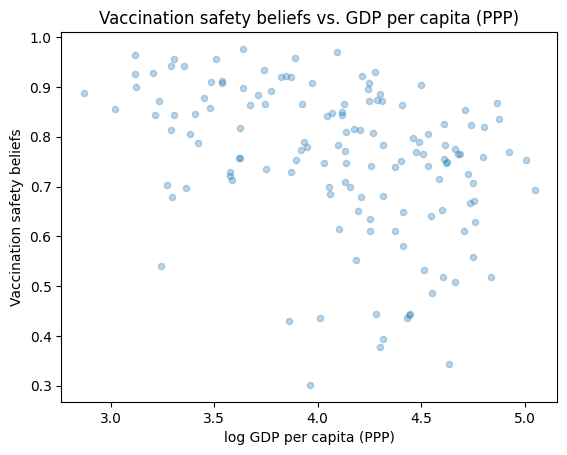

In [7]:
df.plot.scatter(x='log_gdp', y='vaccinesafe', alpha=0.3)
plt.xlabel('log GDP per capita (PPP)')
plt.ylabel('Vaccination safety beliefs')
plt.title('Vaccination safety beliefs vs. GDP per capita (PPP)')
plt.show()

The following function puts a label next to the data point for a given country.

In [8]:
def plot_name(df, name):
    index = df['country'] == name
    x = df.loc[index, 'log_gdp']
    y = df.loc[index, 'vaccinesafe']
    plt.text(x.iloc[0], y.iloc[0], name)

Here's the scatter plot again with a few countries labeled.

If there are other countries you are interested in, feel free to add them.

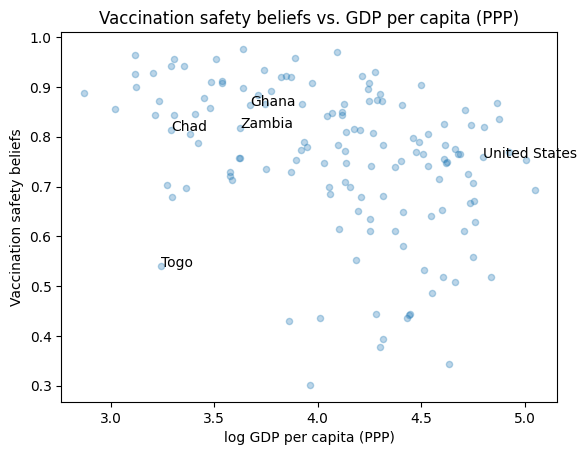

In [9]:
df.plot.scatter(x='log_gdp', y='vaccinesafe', alpha=0.3)

plot_name(df, 'Ghana')
plot_name(df, 'Togo')
plot_name(df, 'Chad')
plot_name(df, 'Zambia')
plot_name(df, 'United States')
plt.xlabel('log GDP per capita (PPP)')
plt.ylabel('Vaccination safety beliefs')
plt.title('Vaccination safety beliefs vs. GDP per capita (PPP)')
plt.show()

For the next version of this figure, I want to label countries in Africa.  The following cell adds a Boolean column to `df` that is `True` for each country where `region` ends with `'Africa'`.

It uses a [list comprehension](http://greenteapress.com/thinkpython2/html/thinkpython2020.html#sec224).

In [10]:
df['is_africa'] = [s.endswith('Africa') for s in df['region']]

Pandas uses Pyplot to generate scatter plots; one limitation is that Pyplot does not easily generate interactive figures.

However, there's another library that does: Plotly.

Here's a scatter plot using Plotly.  If you see a data point that looks interesting, you can hover over it to get more information.

In [11]:
px.scatter(df, x="log_gdp", 
           y="vaccinesafe", 
           color='is_africa',
           hover_name='country')

In [12]:
px.scatter(df, x="log_gdp", 
           y="trustscience", 
           color='is_africa',
           hover_name='country')

In [13]:
px.scatter(df, x="log_gdp", 
           y="trustdoctor", 
           color='is_africa',
           hover_name='country')

In [14]:
px.scatter(df, x="incomegroup", 
           y="vaccinesafe", 
           color='is_africa',
           hover_name='country')

In [15]:
px.scatter(df, x="trustdoctor", 
           y="vaccinesafe", 
           color='is_africa',
           hover_name='country')

In [16]:
px.scatter(df, x="trustscience", 
           y="vaccinesafe", 
           color='is_africa',
           hover_name='country')

## Linear regression

In [17]:
df["trustsiencetimestrustdoctor"] = df["trustscience"] * df["trustdoctor"]
df["trustsciencesquared"] = df["trustscience"] ** 2
df["trustdoctorsquared"] = df["trustdoctor"] ** 2
df["log_gdp_squared"] = df["log_gdp"] ** 2

formula = 'vaccinesafe ~ log_gdp + trustscience + trustdoctor'
results = smf.ols(formula, data=df).fit()

In [18]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            vaccinesafe   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     16.25
Date:                Sat, 07 Jun 2025   Prob (F-statistic):           4.32e-09
Time:                        09:25:13   Log-Likelihood:                 91.692
No. Observations:                 141   AIC:                            -175.4
Df Residuals:                     137   BIC:                            -163.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.0461      0.095     11.043      0.000       0.859       1.233
log_gdp         -0.1292      0.028     -4.623      0.000      -0.185      -0.074
trustscience    -0.3303      0.136     -2.427      0.017      -0.599      -0.061
trustdoctor      0.6038      0.129      4.687      0.000       0.349       0.859
==============================================================================
Omnibus:                       20.433   Durbin-Watson:                   1.661
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               24.341
Skew:                          -0.933   Prob(JB):                     5.18e-06
Kurtosis:                       3.815   Cond. No.                         68.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""